<a href="https://colab.research.google.com/github/clip78/SHARE-seq-alignmentV2/blob/main/notebooks/test_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook explains processing example 2D and 3D images using the Cellpose package on Google Colab using the GPU.

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

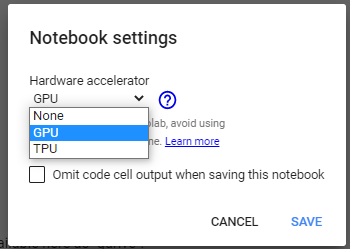

### Install Cellpose-SAM

In [2]:
!pip install cellpose[dino]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 98.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


Check GPU and instantiate model - will download weights.

In [1]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-06-01 17:34:47,937 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-06-01 17:34:47,938 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-06-01 17:34:48,452 [INFO] ** TORCH CUDA version installed and working. **
2026-06-01 17:34:48,453 [INFO] ** TORCH CUDA version installed and working. **
2026-06-01 17:34:48,454 [INFO] >>>> using GPU (CUDA)
2026-06-01 17:34:51,369 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:06<00:00, 200MB/s]


### Download example images

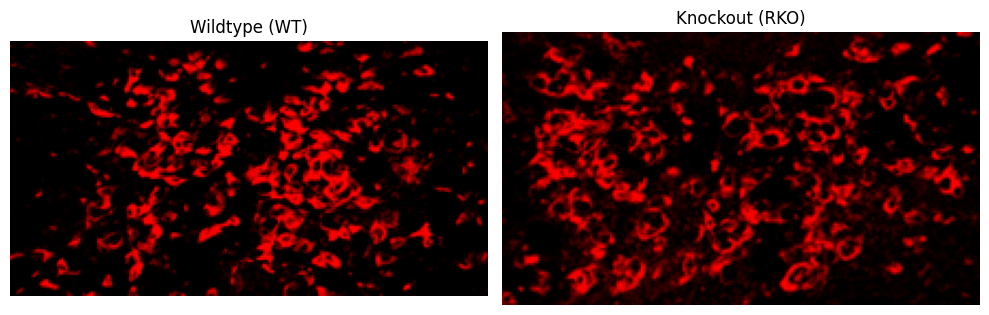

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import utils, io

wt = "Picture1wt.tif"
rko = "Picture1rko.tif"

img_wt = io.imread(wt)
img_rko = io.imread(rko)

# Use your images for the analysis
imgs = [img_wt, img_rko]

plt.figure(figsize=(10,5))
for i, img in enumerate(imgs):
    plt.subplot(1, 2, 1 + i)
    # Check if image is 3D (channels first) or 2D and display accordingly
    if img.ndim == 3:
        plt.imshow(img.transpose(1, 2, 0) if img.shape[0] < img.shape[2] else img)
    else:
        plt.imshow(img, cmap="gray")
    plt.title(f"{'Wildtype (WT)' if i==0 else 'Knockout (RKO)'}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Run Cellpose-SAM

In [4]:
masks_pred, flows, styles = model.eval(imgs, niter=1000) # using more iterations for bacteria


2026-06-01 17:35:49,585 [INFO] 0%|          | 0/2 [00:00<?, ?it/s]


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


2026-06-01 17:35:51,353 [INFO] 100%|##########| 2/2 [00:01<00:00,  1.13it/s]


In [5]:
#@title Tune Segmentation Parameters
# Increase sensitivity by lowering cellprob_threshold
# Default is 0.0. Try -2.0 or -4.0 to detect more cells.
flow_threshold = 0.6 #@param {type:"slider", min:0.0, max:1.0, step:0.1}
cellprob_threshold = -4 #@param {type:"slider", min:-6.0, max:6.0, step:0.5}

print(f'Running evaluation with flow_threshold={flow_threshold} and cellprob_threshold={cellprob_threshold}')

masks_pred, flows, styles = model.eval(imgs,
                                       channels=[0,0],
                                       flow_threshold=flow_threshold,
                                       cellprob_threshold=cellprob_threshold,
                                       niter=1000)

print('Done. Run the visualization cell below to see the updated results.')

Running evaluation with flow_threshold=0.6 and cellprob_threshold=-4
2026-06-01 17:36:04,225 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-06-01 17:36:05,468 [INFO] 100%|##########| 2/2 [00:01<00:00,  1.61it/s]
Done. Run the visualization cell below to see the updated results.


plot results

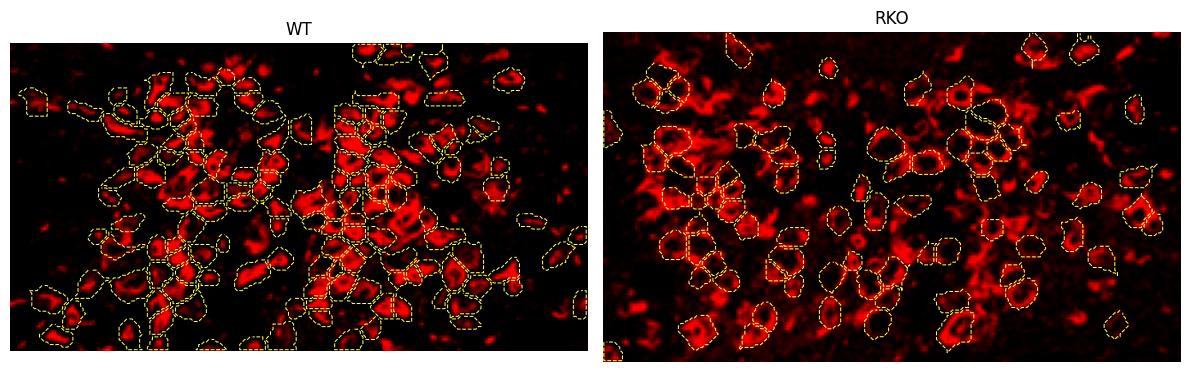

In [6]:
from cellpose import transforms, plot

titles = ["WT", "RKO"]

plt.figure(figsize=(12, 6))
for iex in range(len(imgs)):
    img = imgs[iex].copy()

    # Convert HWC (standard image) to CHW for Cellpose normalization if necessary
    if img.shape[-1] == 3:
        img = img.transpose(2, 0, 1)

    img = np.clip(transforms.normalize_img(img, axis=0), 0, 1) # normalize images

    ax = plt.subplot(1, 2, iex + 1)

    # Display as RGB
    if img.ndim == 3:
        # transpose back to HWC for imshow
        ax.imshow(img.transpose(1, 2, 0))
    else:
        ax.imshow(img, cmap="gray")

    # Draw predicted outlines
    outlines_pred = utils.outlines_list(masks_pred[iex])
    for o in outlines_pred:
        plt.plot(o[:,0], o[:,1], color=[1, 1, 0.3], lw=0.75, ls="--")

    ax.set_title(titles[iex])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
from cellpose import io
import tifffile

# Option 1: Using Cellpose's built-in saver
# This saves masks, flows, and outlines in a format cellpose can reload later
io.save_masks(imgs, masks_pred, flows, file_names=['WT_results', 'RKO_results'], savedir='.', save_txt=True)

# Option 2: Saving just the mask images as standard TIFs for other software (ImageJ, etc.)
tifffile.imwrite('WT_mask.tif', masks_pred[0])
tifffile.imwrite('RKO_mask.tif', masks_pred[1])

print("Masks saved as WT_mask.tif and RKO_mask.tif")

Masks saved as WT_mask.tif and RKO_mask.tif


In [9]:
import numpy as np
import pandas as pd
from skimage.measure import regionprops_table
from skimage.io import imread

# 1. Load your Cellpose-SAM outputs
# 'masks' should be the 2D integer label array saved from your segmentation
masks = imread('RKO_mask.tif')
intensity_img = imread('Picture1rko.tif') # Optional: for intensity metrics

# 2. Define the morphological features to extract
# 'eccentricity' or 'axes lengths' help calculate aspect ratio
properties = [
    'label',
    'area',
    'perimeter',
    'solidity',
    'eccentricity',
    'intensity_mean'  # Captures if the interior signal drops (hollow ring effect)
]

# 3. Extract features into a dictionary
props_dict = regionprops_table(
    label_image=masks,
    intensity_image=intensity_img,
    properties=properties
)

# 4. Convert to Pandas DataFrame and calculate custom metrics
df = pd.DataFrame(props_dict)

# Calculate Circularity: (4 * pi * Area) / (Perimeter^2)
df['circularity'] = (4 * np.pi * df['area']) / (df['perimeter'] ** 2)

# Calculate Aspect Ratio from eccentricity: 1 / sqrt(1 - eccentricity^2)
df['aspect_ratio'] = 1 / np.sqrt(1 - df['eccentricity']**2)

# 5. Clean up noise (optional edge/size filtering)
# Remove tiny fragments or huge artifacts
min_size = 50  # pixels
max_size = 5000
df_filtered = df[(df['area'] >= min_size) & (df['area'] <= max_size)]

# 6. Save results for statistical plotting
df_filtered.to_csv('RKO_neuron_morphology_results.csv', index=False)
print(f"Successfully quantified {len(df_filtered)} neurons.")

Successfully quantified 78 neurons.


In [10]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp

# Assuming 'df_combined' is your merged WT and RKO DataFrame from the graphing step

metrics = ['area', 'circularity', 'solidity', 'aspect_ratio']

print("--- Statistical Analysis: WT vs RKO ---")

for metric in metrics:
    # Isolate the data for each genotype
    wt_data = df_combined[df_combined['Genotype'] == 'WT'][metric]
    rko_data = df_combined[df_combined['Genotype'] == 'RKO'][metric]

    # 1. Mann-Whitney U test (Testing difference in Medians)
    stat_mwu, pval_mwu = mannwhitneyu(wt_data, rko_data, alternative='two-sided')

    # 2. Kolmogorov-Smirnov test (Testing difference in Distributions)
    stat_ks, pval_ks = ks_2samp(wt_data, rko_data)

    print(f"\nMetric: {metric.upper()}")
    print(f"  Mann-Whitney U p-value : {pval_mwu:.2e} " + ("(Significant ***)" if pval_mwu < 0.05 else "(Not Significant)"))
    print(f"  K-S Test p-value       : {pval_ks:.2e} " + ("(Significant ***)" if pval_ks < 0.05 else "(Not Significant)"))

--- Statistical Analysis: WT vs RKO ---


NameError: name 'df_combined' is not defined

/tmp/ipykernel_4625/3267189745.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4625/3267189745.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4625/3267189745.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_4625/3267189745.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


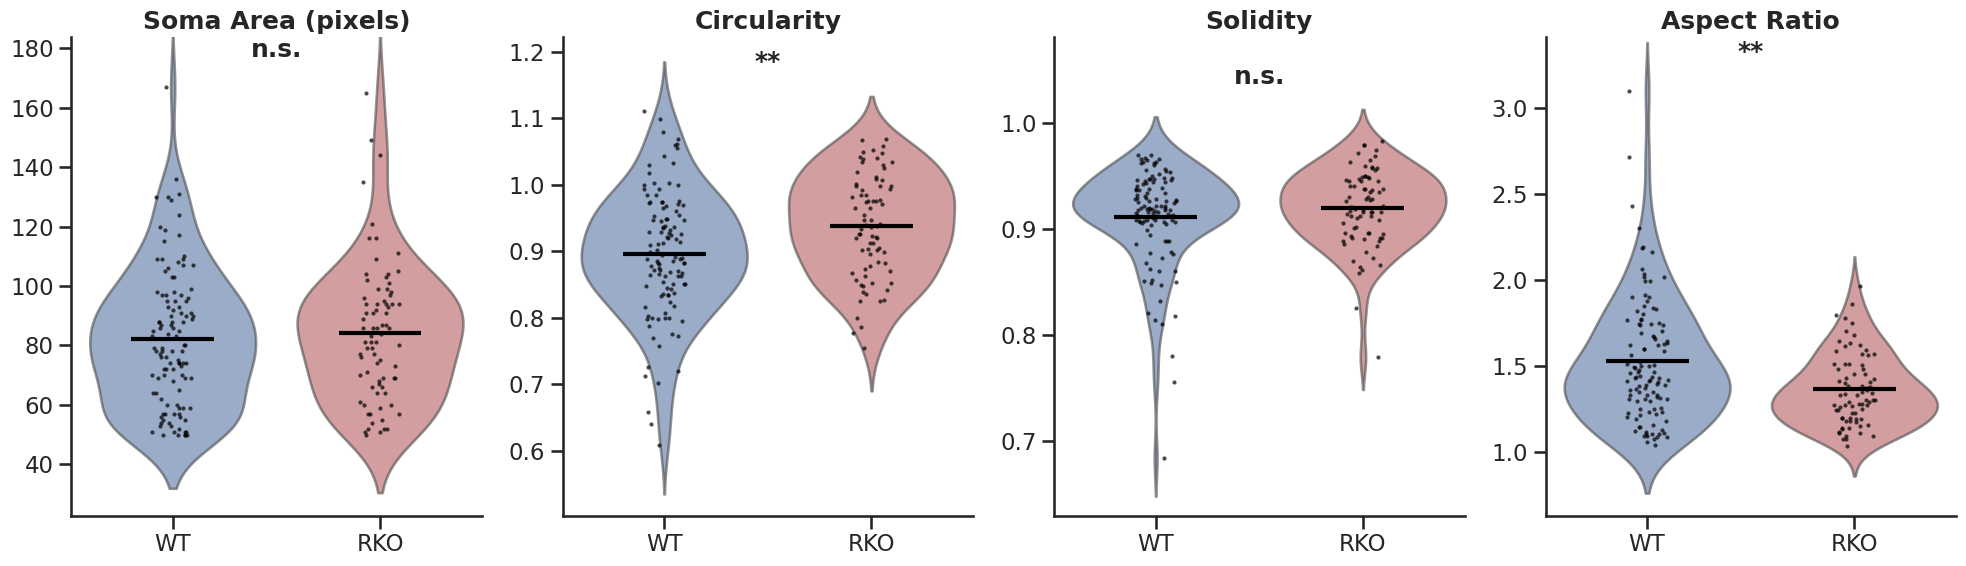

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# 1. Define significance mapping function
def get_sig_stars(p):
    """Returns the significance stars string for a given p-value."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# 2. Load your quantified data
# Ensure these CSVs are in the same directory as your script
df_wt = pd.read_csv('WT_neuron_morphology_results.csv')
df_rko = pd.read_csv('RKO_neuron_morphology_results.csv')

# Add Genotype column and combine
df_wt['Genotype'] = 'WT'
df_rko['Genotype'] = 'RKO'
df_combined = pd.concat([df_wt, df_rko], ignore_index=True)

# 3. Set up the visual style for publication
sns.set_theme(style="ticks", context="talk")

# Define the metrics to plot and their readable titles
metrics_to_plot = {
    'area': 'Soma Area (pixels)',
    'circularity': 'Circularity',
    'solidity': 'Solidity',
    'aspect_ratio': 'Aspect Ratio'
}

# 4. Create a multi-panel figure
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
palette = {'WT': '#4C72B0', 'RKO': '#C44E52'} # Blue and Red

# 5. Main Loop: Plot, calculate stats, and annotate
for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]

    # Isolate data for the statistical test
    wt_data = df_combined[df_combined['Genotype'] == 'WT'][metric]
    rko_data = df_combined[df_combined['Genotype'] == 'RKO'][metric]

    # Calculate statistics (Mann-Whitney U test)
    stat_mwu, pval_mwu = mannwhitneyu(wt_data, rko_data, alternative='two-sided')

    # Draw the violin plot
    sns.violinplot(
        data=df_combined, x='Genotype', y=metric, ax=ax,
        palette=palette, inner=None, alpha=0.6
    )

    # Overlay the individual cell data points (strip plot)
    sns.stripplot(
        data=df_combined, x='Genotype', y=metric, ax=ax,
        color='black', alpha=0.7, size=3, jitter=True
    )

    # --- NEW: ADD MEAN BARS ---
    # Calculate the mean for each group
    mean_wt = wt_data.mean()
    mean_rko = rko_data.mean()

    # In Seaborn categorical plots, the first category (WT) is centered at x=0,
    # and the second (RKO) is centered at x=1.
    # A width of 0.4 makes the bar span across the thickest part of the violin.
    bar_width = 0.4

    # Draw thick black lines for the mean (zorder=5 ensures they sit on top of the dots)
    ax.hlines(y=mean_wt, xmin=0 - bar_width/2, xmax=0 + bar_width/2,
              color='black', linewidth=3, zorder=5)

    # Draw for RKO at x=1
    ax.hlines(y=mean_rko, xmin=1 - bar_width/2, xmax=1 + bar_width/2,
              color='black', linewidth=3, zorder=5)
    # --------------------------

    # Calculate y-coordinate for the significance stars
    y_max = df_combined[metric].max()
    y_buffer = y_max * 0.05 # Add 5% buffer above the max value
    y_pos = y_max + y_buffer

    # Get stars based on the calculated p-value and annotate
    stars = get_sig_stars(pval_mwu)
    ax.text(0.5, y_pos, stars, ha='center', va='bottom', fontweight='bold', fontsize=18)

    # Formatting the axes
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Extend the y-axis limit slightly so the stars are not cut off by the plot boundary
    ax.set_ylim(top=y_pos + (y_max * 0.05))

# 6. Final layout adjustments and save
plt.tight_layout()
sns.despine()

# Save as high-res graphic (bbox_inches='tight' ensures stars aren't cropped)
plt.savefig('WT_vs_RKO_Morphology_Comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('WT_vs_RKO_Morphology_Comparison.pdf', bbox_inches='tight')
plt.show()